<a href="https://colab.research.google.com/github/Luca-1221/MyMIS433/blob/main/Copy_of_regression_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression Models

In [72]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

import seaborn as sns

In [73]:
diamonds = sns.load_dataset('diamonds')
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [74]:
diamonds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [75]:
diamonds.describe(include='all')

,carat,cut,color,clarity,depth,table,price,x,y,z
count,53940.000000,53940,53940,53940,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
unique,NaN,5,7,8,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Ideal,G,SI1,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,21551,11292,13065,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.797940,NaN,NaN,NaN,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,NaN,NaN,NaN,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,NaN,NaN,NaN,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,NaN,NaN,NaN,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,NaN,NaN,NaN,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,NaN,NaN,NaN,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000


In our exploratory data analysis (EDA), we’ve seen some surprising relationships between the quality of diamonds and their price: low quality diamonds (poor cuts, bad colours, and inferior clarity) have higher prices.

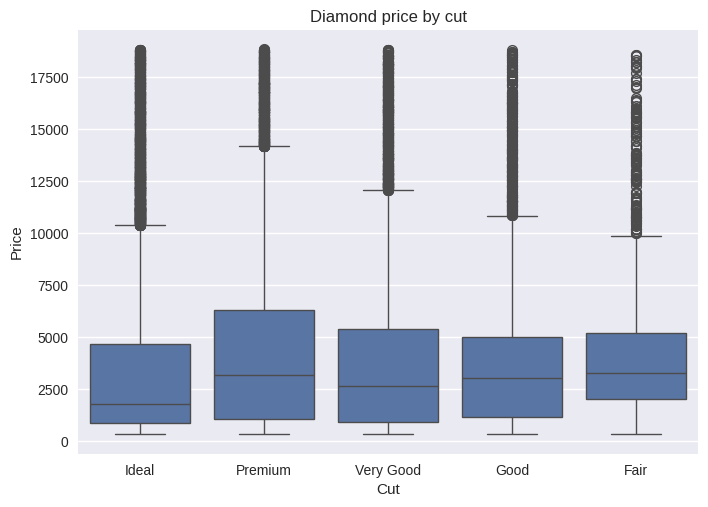

In [76]:
# Fair cuts have higher price?
fig, ax = plt.subplots()
sns.boxplot(data=diamonds, x='cut', y='price', ax=ax)
ax.set_xlabel("Cut")
ax.set_ylabel("Price")
ax.set_title("Diamond price by cut")
plt.show()

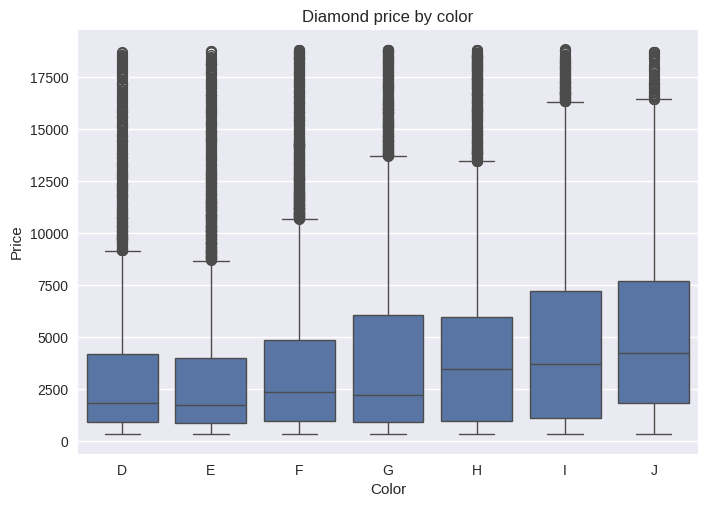

In [77]:
# The worst diamond color is J (slightly yellow)
fig, ax = plt.subplots()
sns.boxplot(data=diamonds, x='color', y='price', ax=ax)
ax.set_xlabel("Color")
ax.set_ylabel("Price")
ax.set_title("Diamond price by color")
plt.show()

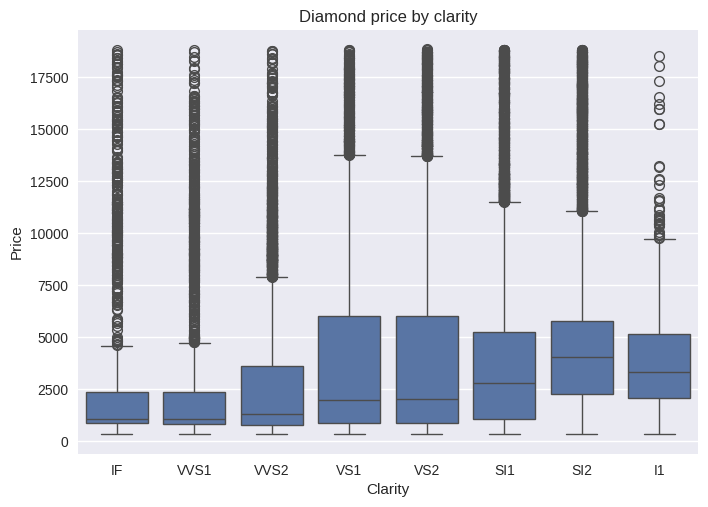

In [78]:
# The worst clarity is I1 (inclusions visible to the naked eye).
fig, ax = plt.subplots()
sns.boxplot(data=diamonds, x='clarity', y='price', ax=ax)
ax.set_xlabel("Clarity")
ax.set_ylabel("Price")
ax.set_title("Diamond price by clarity")
plt.show()

Do these charts mean lower quality diamonds have higher prices? If that's the case, why do people pay higher prices for lower quality?

Do not forget there is an important confounding variable: the weight (carat) of the diamond. The weight of the diamond is the single most important factor for determining the price of the diamond, and lower quality diamonds tend to be larger.

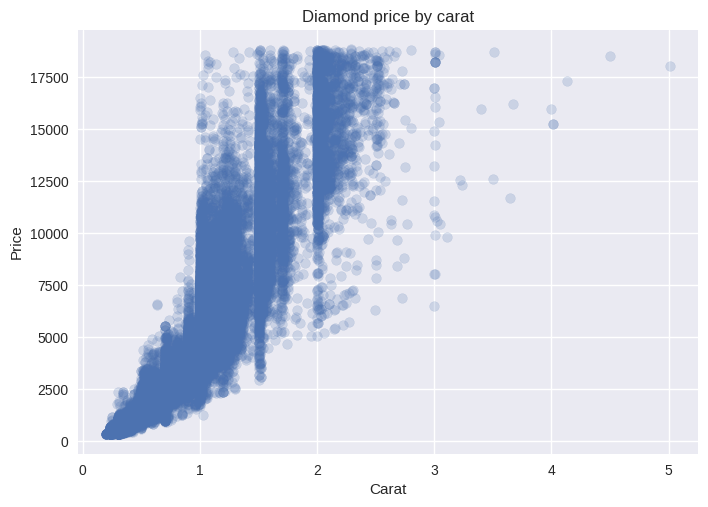

In [79]:
fig, ax = plt.subplots()
ax.scatter(diamonds['carat'], diamonds['price'], alpha=0.2)
ax.set_xlabel("Carat")
ax.set_ylabel("Price")
ax.set_title("Diamond price by carat")
plt.show()

## Build a Simple Regression Model for Diamond Price

We build a simple regression model to predict diamond price by carat.

In [80]:
# Use sklearn for linear regression
from sklearn.linear_model import LinearRegression

In [81]:
diamonds_y = diamonds['price']
diamonds_y

,price
0,326
1,326
2,327
3,334
4,335
...,...
53935,2757
53936,2757
53937,2757
53938,2757


In [82]:
# X as a dataframe (numpy array)
diamonds_X = diamonds[['carat']]
diamonds_X

,carat
0,0.23
1,0.21
2,0.23
3,0.29
4,0.31
...,...
53935,0.72
53936,0.72
53937,0.70
53938,0.86


In [83]:
lm1 = LinearRegression()
lm1.fit(diamonds_X, diamonds_y)

LinearRegression()

In [84]:
print(lm1.intercept_, lm1.coef_)

-2256.360580045403 [7756.42561797]


In [85]:
# R^2 of the model
lm1.score(diamonds_X, diamonds_y)

0.8493305264354858

In [86]:
# Calculate the predicted price
diamonds_y_pred = lm1.predict(diamonds_X)

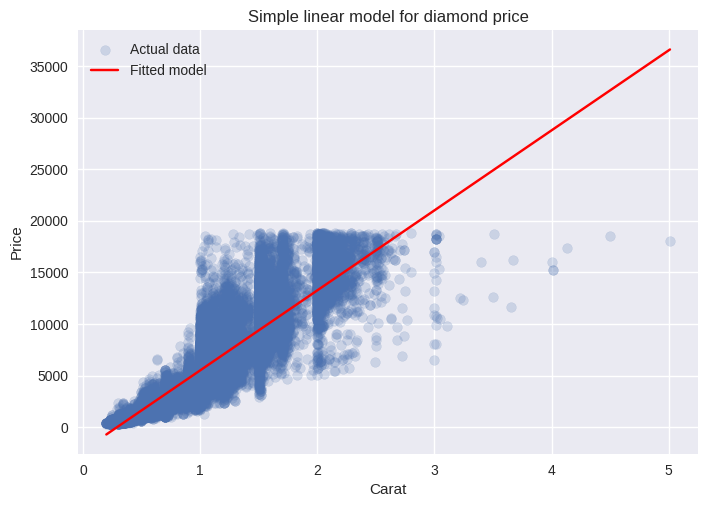

In [87]:
carat_grid = np.linspace(diamonds['carat'].min(), diamonds['carat'].max(), 200).reshape(-1, 1)
price_grid_pred = lm1.predict(pd.DataFrame(carat_grid, columns=['carat']))

fig, ax = plt.subplots()
ax.scatter(diamonds['carat'], diamonds['price'], alpha=0.2, label="Actual data")
ax.plot(carat_grid, price_grid_pred, color="red", label="Fitted model")
ax.set_xlabel("Carat")
ax.set_ylabel("Price")
ax.set_title("Simple linear model for diamond price")
ax.legend()
plt.show()

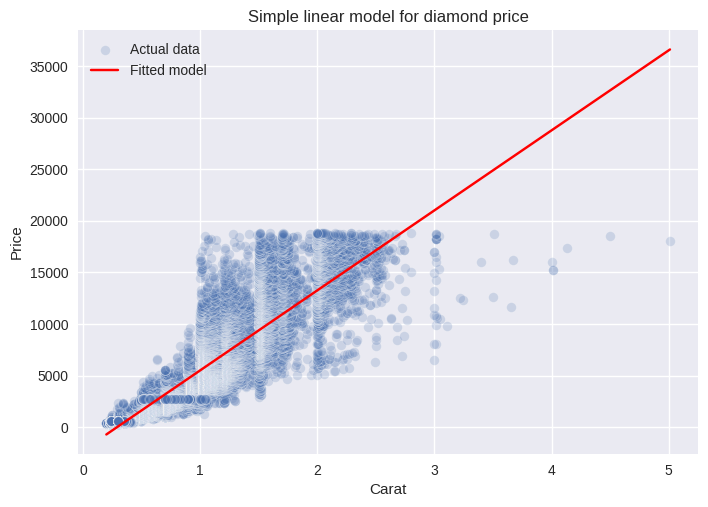

In [88]:
fig, ax = plt.subplots()
sns.scatterplot(data=diamonds, x='carat', y='price', alpha=0.2, label="Actual data", ax=ax)
ax.plot(carat_grid, price_grid_pred, color="red", label="Fitted model")
ax.set_xlabel("Carat")
ax.set_ylabel("Price")
ax.set_title("Simple linear model for diamond price")
ax.legend()
plt.show()

In [89]:
# RMSE: This indicates how off the predicted values are from the actual values.
from sklearn.metrics import root_mean_squared_error
lm1_rmse = root_mean_squared_error(diamonds_y, diamonds_y_pred)
lm1_rmse

1548.5331930613174

## Improving the model

Next, let's make a few tweaks to our model:
- Remove the outliers (big diamonds)
- Include other variables
- Examine non-linearity

### Remove outliers

In [90]:
# How many diamonds are larger than 2.5 carats (99.7% of the data)
bigrock = diamonds.carat>2.5
bigrock.value_counts(normalize=True)

,proportion
carat,
False,0.997664
True,0.002336


In [91]:
# Focus on diamonds smaller than 2.5 carats.
df = diamonds[diamonds.carat<=2.5]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53814 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53814 non-null  float64 
 1   cut      53814 non-null  category
 2   color    53814 non-null  category
 3   clarity  53814 non-null  category
 4   depth    53814 non-null  float64 
 5   table    53814 non-null  float64 
 6   price    53814 non-null  int64   
 7   x        53814 non-null  float64 
 8   y        53814 non-null  float64 
 9   z        53814 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.4 MB


In [92]:
df = df.reset_index().drop(columns=['index'])
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53809,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53810,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53811,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53812,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [93]:
df_X = df[['carat']]
df_y = df['price']

In [94]:
# Build a new linear model using data without the outliers
lm2 = LinearRegression()
lm2.fit(df_X, df_y)

LinearRegression()

In [95]:
print(lm2.intercept_, lm2.coef_)

-2330.655504678868 [7862.1680473]


In [96]:
# R^2 of the model
lm2.score(df_X, df_y)

0.8519722572415094

In [97]:
# Calculate the predicted price using the new model
y_pred = lm2.predict(df_X)

In [98]:
# Estimate the RMSE
root_mean_squared_error(df_y, y_pred)

1520.698006853508

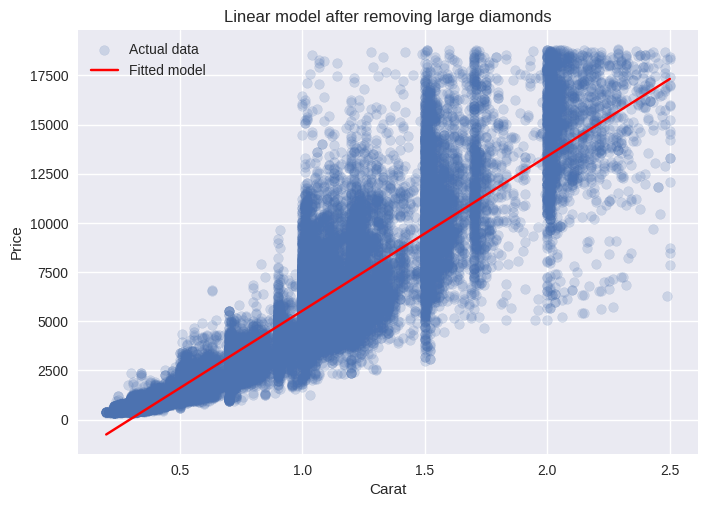

In [99]:
carat_grid = np.linspace(df['carat'].min(), df['carat'].max(), 200).reshape(-1, 1)
price_grid_pred = lm2.predict(pd.DataFrame(carat_grid, columns=['carat']))

fig, ax = plt.subplots()
ax.scatter(df['carat'], df['price'], alpha=0.2, label="Actual data")
ax.plot(carat_grid, price_grid_pred, color="red", label="Fitted model")
ax.set_xlabel("Carat")
ax.set_ylabel("Price")
ax.set_title("Linear model after removing large diamonds")
ax.legend()
plt.show()

### Adding another variable 'cut'

In [100]:
# Let's only keep carat and cut as independent variables.
# You can include more variables (e.g., color, clarity) later if you want.
df_X = df[['carat','cut']]
df_y = df['price']

In [101]:
df_X.head()

,carat,cut
0,0.23,Ideal
1,0.21,Premium
2,0.23,Good
3,0.29,Premium
4,0.31,Good


In [102]:
# 'cut' is a categorical variable with five possible values
df_X.cut.value_counts()

,count
cut,
Ideal,21528
Premium,13745
Very Good,12063
Good,4889
Fair,1589


In [103]:
# You could use sklearn's encoder such as OneHotEncoder to encode this variable.
# Alternatively, use get_dummies() to convert 'cut' to dummy variables, i.e., one-hot encoding
df_X_onehot = pd.get_dummies(df_X)
df_X_onehot.head()

,carat,cut_Ideal,cut_Premium,cut_Very Good,cut_Good,cut_Fair
0,0.23,True,False,False,False,False
1,0.21,False,True,False,False,False
2,0.23,False,False,False,True,False
3,0.29,False,True,False,False,False
4,0.31,False,False,False,True,False


In [104]:
# To differentiate the five levels of cut, we only need to keep four dummy variables
df_X1 = df_X_onehot[['carat','cut_Ideal','cut_Premium','cut_Very Good','cut_Good']]

In [105]:
# Build a new model
lm_onehot = LinearRegression()
lm_onehot.fit(df_X1, df_y)

LinearRegression()

In [106]:
# Print the intercept and coefficients
print(lm_onehot.intercept_, lm_onehot.coef_)

-3895.0408642002185 [7974.56625425 1751.30245509 1379.87435057 1452.57396734 1063.00747392]


**Question: How to interpret these coefficients?**

In [107]:
# R^2
lm_onehot.score(df_X1, df_y)

0.8590074959441552

In [108]:
# RMSE
y_pred = lm_onehot.predict(df_X1)

root_mean_squared_error(df_y, y_pred)

1484.121409859559

### Encode 'cut' with an ordinal encoder
With the knowledge that the five values of cut, ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], indicate the quality from low to high, we could also encode this variable using an ordinal encoder (0, 1, 2, 3, 4).

In [109]:
# select the variable to be encoded
cat_df = df[['cut']]
cat_df.head()

,cut
0,Ideal
1,Premium
2,Good
3,Premium
4,Good


In [110]:
# OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder
# You can specify the order of values for encoding
ord_encoder = OrdinalEncoder(categories=[['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']])
cat_ord_encoded = ord_encoder.fit_transform(cat_df)
ord_encoder.categories_

[array(['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], dtype=object)]

In [111]:
cat_ord_encoded

array([[4.],
       [3.],
       [1.],
       ...,
       [2.],
       [3.],
       [4.]])

In [112]:
# convert cat_ord_encoded into dataframe
cat_df_ord_encoded = pd.DataFrame(cat_ord_encoded, columns=cat_df.columns)
cat_df_ord_encoded

,cut
0,4.0
1,3.0
2,1.0
3,3.0
4,1.0
...,...
53809,4.0
53810,1.0
53811,2.0
53812,3.0


In [113]:
cat_df.cut.value_counts()

,count
cut,
Ideal,21528
Premium,13745
Very Good,12063
Good,4889
Fair,1589


In [114]:
cat_df_ord_encoded.cut.value_counts()

,count
cut,
4.0,21528
3.0,13745
2.0,12063
1.0,4889
0.0,1589


In [115]:
df_X_ord = pd.concat([df_X[['carat']], cat_df_ord_encoded], axis=1)
df_X_ord

,carat,cut
0,0.23,4.0
1,0.21,3.0
2,0.23,1.0
3,0.29,3.0
4,0.31,1.0
...,...,...
53809,0.72,4.0
53810,0.72,1.0
53811,0.70,2.0
53812,0.86,3.0


In [116]:
# Build a new model
lm_ord = LinearRegression()
lm_ord.fit(df_X_ord, df_y)

LinearRegression()

In [117]:
# Print the intercept and coefficients
print(lm_ord.intercept_, lm_ord.coef_)

-3139.8677974900556 [7943.41866224  256.31917809]


**Question: How to interpret the coefficients?**

In [118]:
# R^2
lm_ord.score(df_X_ord, df_y)

0.8571147927378382

In [119]:
# RMSE
df_y_pred = lm_ord.predict(df_X_ord)

root_mean_squared_error(df_y, df_y_pred)

1494.0497284318856

**Note:** Ordinal encoding assumes that the distance between adjacent quality levels is equal. For example, it treats the difference between Fair and Good the same as the difference between Premium and Ideal. That assumption may or may not be appropriate, so ordinal encoding should be used thoughtfully.

### Non-linearity

The relationship between carat and price seems to be non-linear.

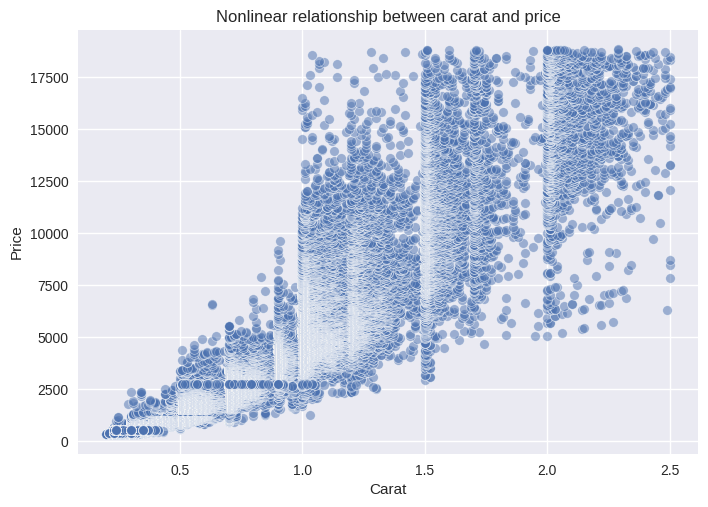

In [120]:
fig, ax = plt.subplots()
sns.scatterplot(data=df, x='carat', y='price', alpha=0.5, ax=ax)
ax.set_xlabel("Carat")
ax.set_ylabel("Price")
ax.set_title("Nonlinear relationship between carat and price")
plt.show()

In [121]:
df['log_price'] = np.log(df.price)
df['log_price']

,log_price
0,5.786897
1,5.786897
2,5.789960
3,5.811141
4,5.814131
...,...
53809,7.921898
53810,7.921898
53811,7.921898
53812,7.921898


In [122]:
df['log_carat'] = np.log(df.carat)

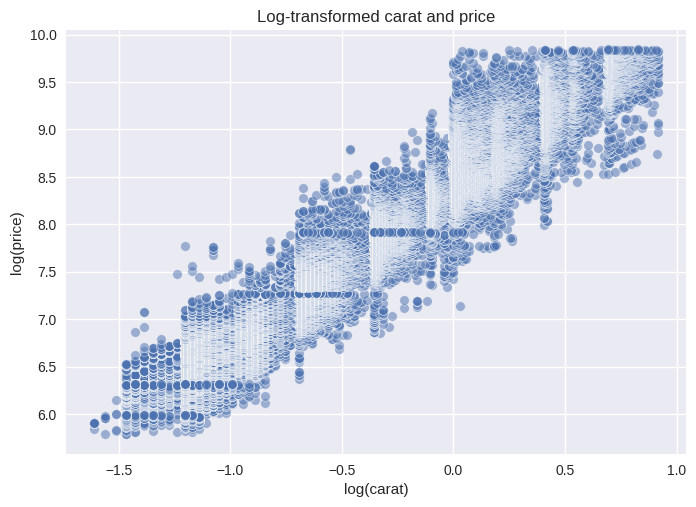

In [123]:
fig, ax = plt.subplots()
sns.scatterplot(data=df, x='log_carat', y='log_price', alpha=0.5, ax=ax)
ax.set_xlabel("log(carat)")
ax.set_ylabel("log(price)")
ax.set_title("Log-transformed carat and price")
plt.show()

In [124]:
df_X_log = df[['log_carat']]
df_X_log

,log_carat
0,-1.469676
1,-1.560648
2,-1.469676
3,-1.237874
4,-1.171183
...,...
53809,-0.328504
53810,-0.328504
53811,-0.356675
53812,-0.150823


In [125]:
df_y_log = df['log_price']
df_y_log

,log_price
0,5.786897
1,5.786897
2,5.789960
3,5.811141
4,5.814131
...,...
53809,7.921898
53810,7.921898
53811,7.921898
53812,7.921898


In [126]:
lm_log = LinearRegression()
lm_log.fit(df_X_log, df_y_log)

LinearRegression()

In [127]:
# Print the intercept and coefficients
print(lm_log.intercept_, lm_log.coef_)

8.45214175869571 [1.68137106]


**How to interpret the coefficients?**

In [128]:
# R^2
lm_log.score(df_X_log, df_y_log)

0.9334026253208663

In [129]:
# Make predictions using the new model
# using log_carat to predict log_price
log_y_pred = lm_log.predict(df_X_log)
# You must convert log price back to price
y_pred = np.exp(log_y_pred)

In [130]:
# RMSE
root_mean_squared_error(df_y, y_pred)

1513.8853713352714

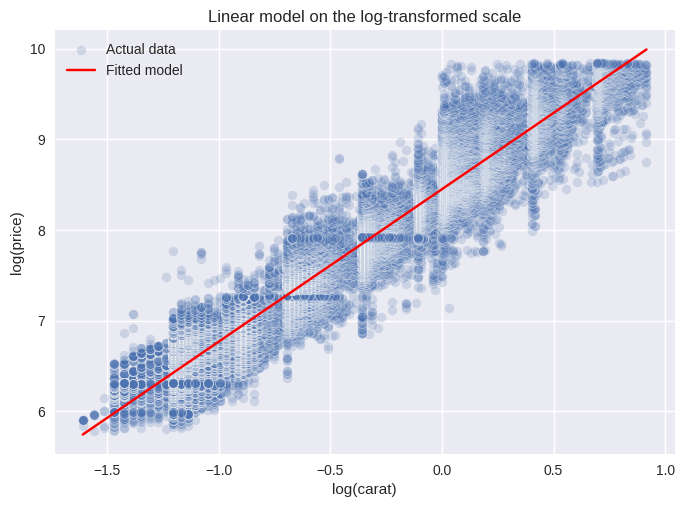

In [131]:
log_carat_grid = np.linspace(df['log_carat'].min(), df['log_carat'].max(), 200).reshape(-1, 1)
log_price_grid_pred = lm_log.predict(pd.DataFrame(log_carat_grid, columns=['log_carat']))

fig, ax = plt.subplots()
sns.scatterplot(data=df, x='log_carat', y='log_price', alpha=0.2, label="Actual data", ax=ax)
ax.plot(log_carat_grid, log_price_grid_pred, color="red", label="Fitted model")
ax.set_xlabel("log(carat)")
ax.set_ylabel("log(price)")
ax.set_title("Linear model on the log-transformed scale")
ax.legend()
plt.show()

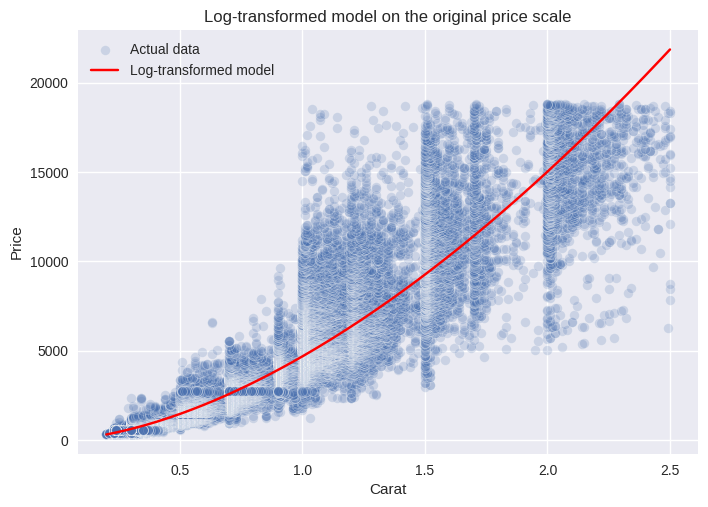

In [132]:
carat_grid = np.linspace(df['carat'].min(), df['carat'].max(), 200).reshape(-1, 1)
log_carat_grid = np.log(carat_grid)
price_grid_pred = np.exp(lm_log.predict(pd.DataFrame(log_carat_grid, columns=['log_carat'])))

fig, ax = plt.subplots()
sns.scatterplot(data=df, x='carat', y='price', alpha=0.2, label="Actual data", ax=ax)
ax.plot(carat_grid, price_grid_pred, color="red", label="Log-transformed model")
ax.set_xlabel("Carat")
ax.set_ylabel("Price")
ax.set_title("Log-transformed model on the original price scale")
ax.legend()
plt.show()

# Assignment

Build another regression model (e.g., including other variables such as color and clarity, adding categorical variable(s) to the log-transformed model). Test its performance.

## Optimal Predictor Selection

First, we need to clean the data by removing any entries where `x`, `y`, or `z` dimensions are zero, as these represent invalid diamond measurements. We will then proceed to test various combinations of features to find the most optimal model.

In [133]:
# Identify and remove rows with zero dimensions
print("Number of rows with x=0:", (df['x'] == 0).sum())
print("Number of rows with y=0:", (df['y'] == 0).sum())
print("Number of rows with z=0:", (df['z'] == 0).sum())

# Filter out invalid entries where x, y, or z are zero
df_working = df[(df['x'] != 0) & (df['y'] != 0) & (df['z'] != 0)].copy()

print(f"Original df shape: {df.shape}")
print(f"Cleaned df_working shape: {df_working.shape}")

# The log_price and log_carat columns were already created on the filtered `df`.
# We need to ensure they are also present in `df_working` and correctly reflect its data.
# Since df_working is a copy from df after filtering, these columns should be correct.
# Let's re-verify and re-calculate if necessary to be safe.
if 'log_price' not in df_working.columns:
    df_working['log_price'] = np.log(df_working['price'])
if 'log_carat' not in df_working.columns:
    df_working['log_carat'] = np.log(df_working['carat'])

Number of rows with x=0: 8
Number of rows with y=0: 7
Number of rows with z=0: 19
Original df shape: (53814, 12)
Cleaned df_working shape: (53795, 12)


Next, we will prepare all the potential feature sets (numerical and one-hot encoded categorical variables) and iterate through their combinations to find the best model. We will use `log_price` as our target variable.

In [134]:
import itertools
from sklearn.metrics import r2_score

# Define the target variable
y_target = df_working['log_price']
y_original_price = df_working['price'] # For RMSE calculation on original scale

# Prepare numerical features
num_features = ['log_carat', 'depth', 'table', 'x', 'y', 'z']
X_num = df_working[num_features]

# Prepare one-hot encoded categorical features
X_cut = pd.get_dummies(df_working['cut'], prefix='cut', drop_first=True)
X_color = pd.get_dummies(df_working['color'], prefix='color', drop_first=True)
X_clarity = pd.get_dummies(df_working['clarity'], prefix='clarity', drop_first=True)

# List of all feature groups to combine
feature_groups = [
    ('log_carat_only', df_working[['log_carat']]), # Treat log_carat as a standalone group
    ('depth', df_working[['depth']]),
    ('table', df_working[['table']]),
    ('x', df_working[['x']]),
    ('y', df_working[['y']]),
    ('z', df_working[['z']]),
    ('cut', X_cut),
    ('color', X_color),
    ('clarity', X_clarity)
]

best_r2 = -np.inf
best_rmse = np.inf
best_features_names = []
best_model_found = None

all_models_results = []

# Iterate through all combinations of feature groups
for i in range(1, len(feature_groups) + 1):
    for combo in itertools.combinations(feature_groups, i):
        current_features_names = [name for name, _ in combo]

        # Concatenate selected feature dataframes
        X_current = pd.concat([df_features for _, df_features in combo], axis=1)

        # Train the linear regression model
        model = LinearRegression()
        model.fit(X_current, y_target)

        # Predict on log-transformed scale
        log_y_pred = model.predict(X_current)

        # Calculate R-squared on log-transformed scale
        current_r2 = r2_score(y_target, log_y_pred)

        # Convert predictions back to original scale for RMSE calculation
        y_pred_original = np.exp(log_y_pred)
        current_rmse = root_mean_squared_error(y_original_price, y_pred_original)

        all_models_results.append({
            'features': current_features_names,
            'r_squared': current_r2,
            'rmse': current_rmse,
            'model': model
        })

        # Update best model if current model has higher R-squared
        if current_r2 > best_r2:
            best_r2 = current_r2
            best_rmse = current_rmse
            best_features_names = current_features_names
            best_model_found = model

print("\n--- Best Model Found ---")
print(f"Features: {best_features_names}")
print(f"R-squared: {best_r2:.4f}")
print(f"RMSE: {best_rmse:.2f}")

# Display coefficients for the best model (if it exists)
if best_model_found:
    print("Intercept:", best_model_found.intercept_)
    # To print coefficients with their corresponding feature names, we need the final X_current for the best model
    best_X_current = pd.concat([df_features for name, df_features in feature_groups if name in best_features_names], axis=1)
    print("Coefficients:")
    for feature, coef in zip(best_X_current.columns, best_model_found.coef_):
        print(f"  {feature}: {coef:.4f}")



--- Best Model Found ---
Features: ['log_carat_only', 'depth', 'table', 'x', 'y', 'z', 'cut', 'color', 'clarity']
R-squared: 0.9830
RMSE: 769.78
Intercept: 7.918755348440992
Coefficients:
  log_carat: 1.6289
  depth: 0.0049
  table: 0.0005
  x: 0.1343
  y: -0.0012
  z: 0.0043
  cut_Premium: -0.0249
  cut_Very Good: -0.0418
  cut_Good: -0.0771
  cut_Fair: -0.1571
  color_E: -0.0549
  color_F: -0.0950
  color_G: -0.1616
  color_H: -0.2548
  color_I: -0.3786
  color_J: -0.5191
  clarity_VVS1: -0.0946
  clarity_VVS2: -0.1651
  clarity_VS1: -0.2978
  clarity_VS2: -0.3683
  clarity_SI1: -0.5162
  clarity_SI2: -0.6832
  clarity_I1: -1.0935


In [135]:
df_X_cat = df[['cut', 'color', 'clarity']]
df_X_cat_onehot = pd.get_dummies(df_X_cat)

# Combine log_carat with the one-hot encoded categorical features
df_X_new = pd.concat([df[['log_carat']], df_X_cat_onehot], axis=1)
df_y_new = df['log_price']

# Build a new linear model
lm_new = LinearRegression()
lm_new.fit(df_X_new, df_y_new)

# Print the intercept and coefficients
print("Intercept:", lm_new.intercept_)
print("Coefficients:", lm_new.coef_)

# R^2 of the model
r_squared_new = lm_new.score(df_X_new, df_y_new)
print(f"R-squared: {r_squared_new}")

# Make predictions using the new model
# using log_carat and one-hot encoded categories to predict log_price
log_y_pred_new = lm_new.predict(df_X_new)
# Convert log price back to price
y_pred_new = np.exp(log_y_pred_new)

# Calculate RMSE
rmse_new = root_mean_squared_error(df_y, y_pred_new)
print(f"RMSE: {rmse_new}")

Intercept: 8.461232359345878
Coefficients: [ 1.88623913  0.06156009  0.03984971  0.01745505 -0.01959898 -0.09926587
  0.20643912  0.15203475  0.11122145  0.04556152 -0.04452379 -0.16595871
 -0.30477434  0.40493751  0.30988804  0.2380692   0.10262696  0.03235346
 -0.11716896 -0.2810939  -0.68961231]
R-squared: 0.9827876212836506
RMSE: 735.9982454152839


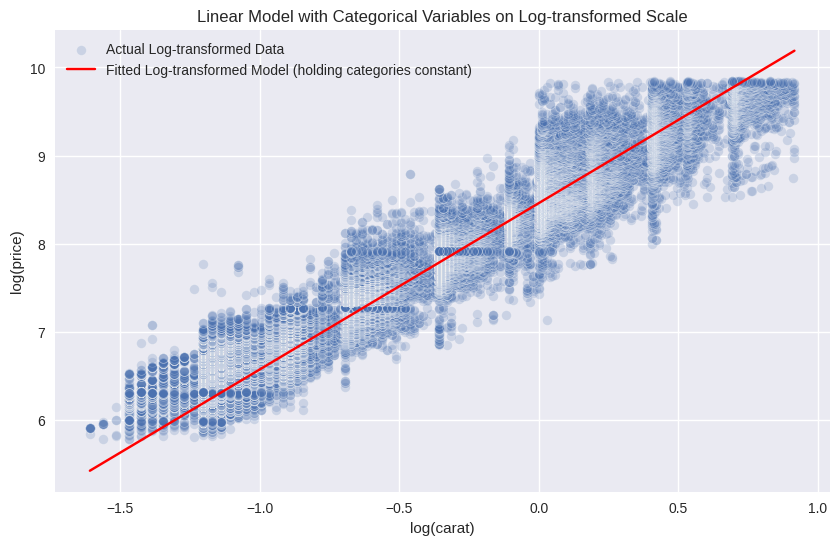

In [136]:
log_carat_grid_new = np.linspace(df['log_carat'].min(), df['log_carat'].max(), 200).reshape(-1, 1)

# Create a dummy DataFrame with the same columns as df_X_new for prediction
# Fill categorical columns with zeros (representing the baseline category if one-hot encoded)
# For simplicity in visualization, we'll assume a 'default' or average effect for categorical variables
# when plotting against log_carat. A more detailed plot might show multiple lines for each category combination.
# For now, we'll create a DataFrame where categorical features are all zeros to see the base log_carat effect.

# Get the columns of the training data for the new model, excluding 'log_carat'
cat_cols_new = [col for col in df_X_new.columns if col != 'log_carat']

# Create a DataFrame for prediction grid
predict_df_new = pd.DataFrame(0, index=range(len(log_carat_grid_new)), columns=df_X_new.columns)
predict_df_new['log_carat'] = log_carat_grid_new

log_price_grid_pred_new = lm_new.predict(predict_df_new)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='log_carat', y='log_price', alpha=0.2, label="Actual Log-transformed Data", ax=ax)
ax.plot(log_carat_grid_new, log_price_grid_pred_new, color="red", label="Fitted Log-transformed Model (holding categories constant)")
ax.set_xlabel("log(carat)")
ax.set_ylabel("log(price)")
ax.set_title("Linear Model with Categorical Variables on Log-transformed Scale")
ax.legend()
plt.grid(True)
plt.show()

To also visualize the model's predictions on the original scale:


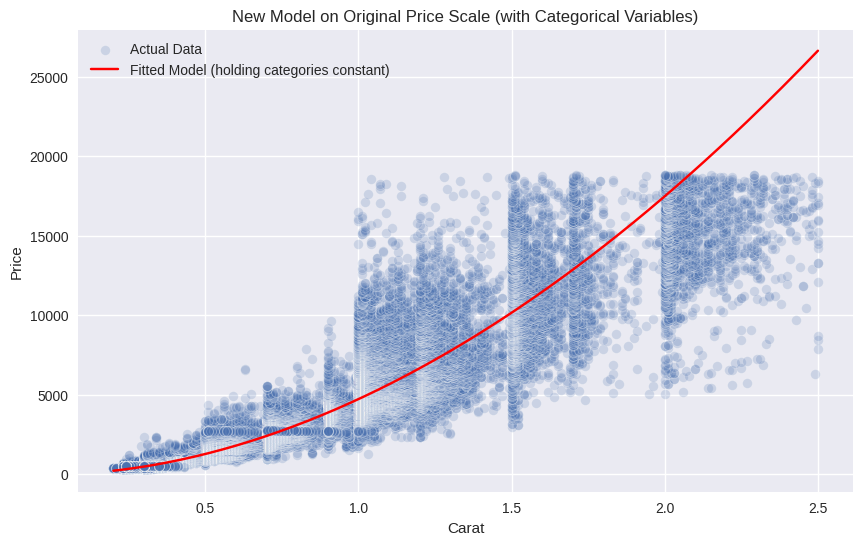

In [137]:
carat_grid_original = np.linspace(df['carat'].min(), df['carat'].max(), 200).reshape(-1, 1)
log_carat_grid_original = np.log(carat_grid_original)

# Similar to the log-scale plot, we'll set categorical features to zero for a baseline visualization.
predict_df_original = pd.DataFrame(0, index=range(len(log_carat_grid_original)), columns=df_X_new.columns)
predict_df_original['log_carat'] = log_carat_grid_original

price_grid_pred_original = np.exp(lm_new.predict(predict_df_original))

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='carat', y='price', alpha=0.2, label="Actual Data", ax=ax)
ax.plot(carat_grid_original, price_grid_pred_original, color="red", label="Fitted Model (holding categories constant)")
ax.set_xlabel("Carat")
ax.set_ylabel("Price")
ax.set_title("New Model on Original Price Scale (with Categorical Variables)")
ax.legend()
plt.grid(True)
plt.show()